In [1]:
from pyinaturalist import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

In [2]:
import time

PARENT_TAXON_ID = 47157 # Lepidoptera

top_species = []

# Fetch 80 results by paginating through 2 pages of 40 items each
for page in range(1, 3):
    response = get_observation_species_counts(
        taxon_id=PARENT_TAXON_ID,
        hrank='species',    
        per_page=40,      
        place_id=42, # Pennsylvania
        page=page
    )
    

    top_species.extend(response.get('results', []))
    time.sleep(1) 


In [3]:
taxa = {}
for i, item in enumerate(top_species, 1):
    taxon_info = item['taxon']
    taxa[taxon_info['id']] = taxon_info['name']
    
taxon_ids = [key for key, value in taxa.items()]
print(taxon_ids)

[48662, 60551, 1455248, 81559, 55626, 60607, 59675, 58523, 82225, 58525, 52925, 1456562, 211100, 1081329, 49133, 63028, 120217, 133631, 58555, 47919, 116681, 60839, 47802, 81677, 52904, 81687, 47916, 54064, 81680, 145659, 58532, 118513, 82379, 81681, 127133, 82792, 143043, 143615, 118927, 143110, 68244, 58478, 48505, 358549, 143440, 83090, 143518, 553984, 118860, 81657, 48094, 81590, 58750, 58564, 82279, 143024, 119789, 58579, 81665, 58481, 58603, 143867, 133447, 52902, 126397, 118930, 121594, 122281, 1671287, 56832, 736797, 48549, 143105, 127460, 154353, 143005, 142990, 143730, 68264, 58531]


In [4]:
# Convert months to middle-of-month day
month_days = np.array([
    15,
    46,
    74,
    105,
    135,
    166,
    196,
    227,
    258,
    288,
    319,
    349
])

days = np.arange(1, 366)

In [5]:
def get_curve(taxon_id):
    histogram = get_observation_histogram(
        taxon_id=taxon_id, 
        place_id=42, 
        quality_grade='research'
    )
    
    months = np.array(list(histogram.keys()))
    observations = np.array(list(histogram.values()))
    
    interpolator = PchipInterpolator(month_days, observations)
    daily_observations = interpolator(days)
    
    # Normalize to maximum = 1
    daily_normalized = daily_observations / daily_observations.max()
    
    return daily_normalized

In [6]:
phenology = {}
for taxon in taxon_ids:
    phenology[taxon] = get_curve(taxon)
    time.sleep(1) 

# Reverse dict to put species with most observations at the top
phenology = dict(reversed(phenology.items()))

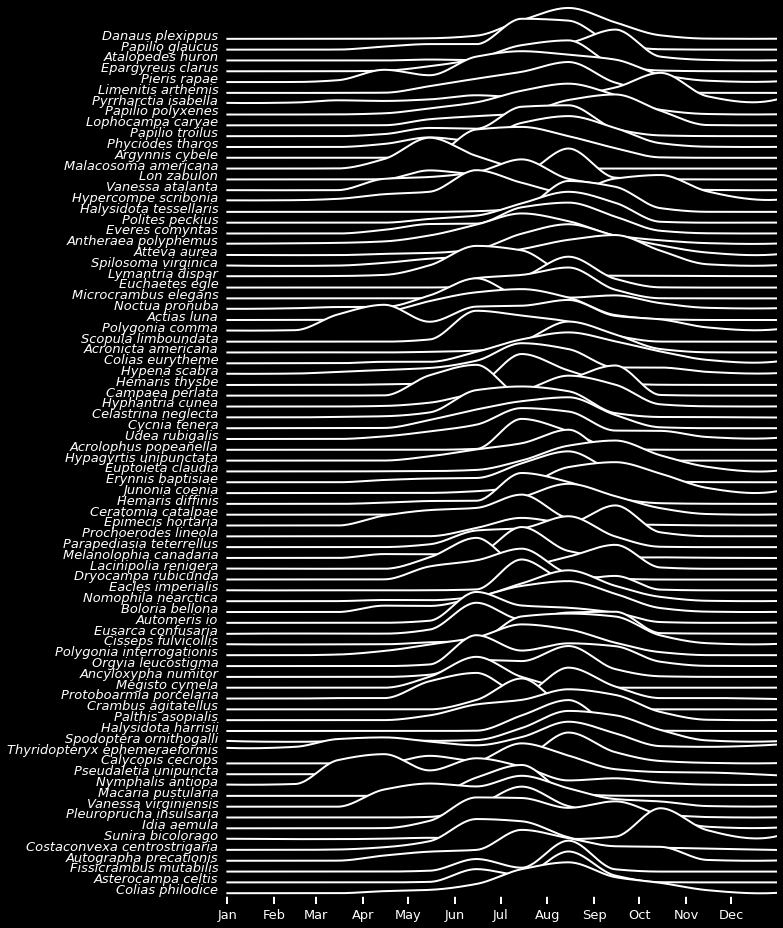

In [7]:
plt.rcParams["pdf.fonttype"] = 42

fig, ax = plt.subplots(figsize=(11, 13))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

spacing = 0.35

for i, (taxon, curve) in enumerate(phenology.items()):

    baseline = i * spacing
    y = baseline + curve

    ax.fill_between(
        days,
        y,
        color="black",
        zorder=len(phenology)-i
    )
    
    
    ax.plot(
        days,
        y,
        linewidth=2,
        color="white",
        zorder=len(phenology)-i
    )

    
    # Species label
    ax.text(
        -5,
        baseline - 0.1,
        taxa[taxon],
        ha="right",
        va="bottom",
        fontsize=13,
        color="white",
        style="italic"
    )

ax.set_xlim(0, 365)
ax.set_ylim(-0.1, (len(phenology) - 1) * spacing + 1.05)

ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


month_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

ax.set_xticks(month_days)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.tick_params(
    axis="x",
    colors="white",
    length=8,
    width=2,
    labelsize=13,
)

plt.tight_layout()
plt.show()

fig.tight_layout()

fig.savefig(
    "butterfly_phenology.pdf",
    format="pdf",
    facecolor="black",
    bbox_inches="tight"
)